In [1]:
from tgt_vis import compute_visibility
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

In [2]:
!pip install plotly

In [3]:
def check_cvz_status(df, max_sep_deg=126.0, good_angle_threshold=0.99):
    """
    Check if target is in the Continuous Viewing Zone (CVZ).
    
    A target is in the CVZ if it can be observed continuously (always has good_angles)
    or if sun-target separation is always beyond the max allowed separation.
    
    Parameters:
    -----------
    df : DataFrame from compute_visibility
    max_sep_deg : float
        Maximum allowed sun-target separation for observations (default 126 deg for Roman)
    good_angle_threshold : float
        Fraction of time with good_angles required to consider in CVZ (default 0.99 = 99%)
    
    Returns:
    --------
    is_cvz : bool
        True if target is in CVZ
    vis_frac : float
        Fraction of year with good visibility
    info_str : str
        Human-readable summary
    """
    good = df["good_angles"].astype(bool).values
    vis_frac = float(np.mean(good))
    
    # Separation in degrees
    separation = np.array([
        x.to_value(u.deg) if hasattr(x, "to_value") else float(x)
        for x in df["separation"].values
    ], dtype=float)
    
    # CVZ if always above max separation OR always has good angles
    always_above_max = np.all(separation > max_sep_deg)
    mostly_good = vis_frac >= good_angle_threshold
    
    is_cvz = always_above_max or mostly_good
    
    # Generate info string
    if always_above_max:
        info_str = f"✓ IN CVZ: Sun-target separation always > {max_sep_deg}°"
    elif mostly_good:
        info_str = f"✓ IN CVZ: Good visibility {vis_frac*100:.1f}% of the year (≥{good_angle_threshold*100:.0f}%)"
    else:
        info_str = f"✗ NOT in CVZ: Good visibility only {vis_frac*100:.1f}% of the year"
    
    return is_cvz, vis_frac, info_str


def plot_visibility_from_df(df, title_suffix="", mask_to_good=False):
    """
    Make standard visibility plots from compute_visibility.df_results
    Assumes df is already sliced to a single (RA, Dec).
    """
    from matplotlib.dates import DateFormatter, MonthLocator
    import pandas as pd

    # --- Check CVZ status ---
    is_cvz, vis_frac, cvz_info = check_cvz_status(df)
    print("\n" + "="*60)
    print(f"CVZ Status for {title_suffix}")
    print("="*60)
    print(cvz_info)
    print(f"Visibility Fraction: {vis_frac*100:.1f}%")
    print("="*60 + "\n")

    # --- X axis: Convert index strings to datetime objects ---
    dates = pd.to_datetime(df.index.astype(str), format='%Y-%j.%f')

    good = df["good_angles"].astype(bool).values

    def arr(col):
        return np.array([
            x.to_value(u.deg) if hasattr(x, "to_value") else float(x)
            for x in df[col].values
        ])

    separation = arr("separation")
    roll = arr("nominal_roll")
    pa_y = arr("pa_obs_y")
    pa_x = arr("pa_fpa_local_x")
    pa_fpa_y = arr("pa_fpa_local_y")

    sunx = arr("sunang_x")
    suny = arr("sunang_y")
    sunz = arr("sunang_z")

    if mask_to_good:
        roll = np.where(good, roll, np.nan)
        pa_y = np.where(good, pa_y, np.nan)
        pa_x = np.where(good, pa_x, np.nan)
        pa_fpa_y = np.where(good, pa_fpa_y, np.nan)
        sunx = np.where(good, sunx, np.nan)
        suny = np.where(good, suny, np.nan)
        sunz = np.where(good, sunz, np.nan)

    # -----------------------
    # 1) Visibility window
    # -----------------------
    plt.figure(figsize=(11, 3))
    plt.step(dates, good.astype(int), where="mid")
    plt.yticks([0, 1], ["Not in FOR", "In FOR"])
    ax = plt.gca()
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    plt.xlabel("Date")
    plt.ylabel("Visibility")
    title = f"Visibility Window {title_suffix}"
    if is_cvz:
        title += " [CVZ]"
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------
    # 2) Sun separation
    # -----------------------
    plt.figure(figsize=(11, 4))
    plt.plot(dates, separation, lw=1.5)
    plt.axhline(54, ls="--", label="Min separation (54°)")
    plt.axhline(126, ls="--", label="Max separation (126°)")
    plt.fill_between(dates, 54, 126, alpha=0.15, label="Observable range")
    ax = plt.gca()
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    plt.xlabel("Date")
    plt.ylabel("Sun–Target Separation (deg)")
    plt.title(f"Sun–Target Separation {title_suffix}")
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------
    # 3) Roll / PAs
    # -----------------------
    plt.figure(figsize=(11, 4))
    plt.plot(dates, roll, label="nominal_roll")
    plt.plot(dates, pa_y, label="pa_obs_y")
    plt.plot(dates, pa_x, label="pa_fpa_local_x")
    plt.plot(dates, pa_fpa_y, label="pa_fpa_local_y")
    ax = plt.gca()
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    plt.xlabel("Date")
    plt.ylabel("Angle (deg)")
    plt.title(f"Roll & Position Angles {title_suffix}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------
    # 4) Sun angles XYZ
    # -----------------------
    plt.figure(figsize=(11, 4))
    plt.plot(dates, sunx, label="sunang_x")
    plt.plot(dates, suny, label="sunang_y")
    plt.plot(dates, sunz, label="sunang_z")
    ax = plt.gca()
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    plt.xlabel("Date")
    plt.ylabel("Angle (deg)")
    plt.title(f"Sun Angles (Obs Frame) {title_suffix}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [4]:
from bokeh.io import output_notebook, show
from bokeh.models import ColumnDataSource, DatetimeTickFormatter, HoverTool, Label, LabelSet
from bokeh.layouts import column, row
from bokeh.plotting import figure
import pandas as pd

output_notebook()

def create_live_4tab_dashboard():
    """
    Creates a Bokeh layout with 4 tabs and live-updating plots.
    - Left: Controls (RA, Dec, start date, duration, sampling)
    - Right: 4 tabs with visibility, separation, roll+PAs, and sun angles plots
    """
    from bokeh.models import TextInput, DatePicker, Slider, Div, Tabs, TabPanel, Title, Button
    
    # ===== CONTROLS =====
    ra_input = TextInput(title="RA (sexagesimal or degrees)", value="06h00m00s", width=350)
    dec_input = TextInput(title="Dec (sexagesimal or degrees)", value="-01d00m00s", width=350)
    start_picker = DatePicker(title="Start date (UTC)", value="2026-01-01", width=350)
    duration_slider = Slider(title="Duration (days)", start=7, end=730, step=1, value=365, width=350)
    cadence_slider = Slider(title="Sampling cadence (days)", start=0.25, end=30.0, step=0.25, value=1.0, width=350)
    
    compute_button = Button(label="Compute", button_type="primary", width=350)
    
    status_div = Div(text="<b>Status:</b> Ready. Adjust parameters and click Compute.", width=350)
    cvz_div = Div(text="<b>CVZ Status:</b> Waiting for computation...", width=350)
    info_div = Div(text="<b>Observable Range:</b> 54 - 126 sun-target separation", width=350)
    
    # ===== DATA SOURCES =====
    source = ColumnDataSource(data=dict(
        dates=[],
        good=[],
        separation=[],
        roll=[],
        pa_obs_y=[],
        sunang_x=[],
        sunang_y=[],
        sunang_z=[],
    ))
    
    sep_limits = ColumnDataSource(data=dict(x=[], y_min=[], y_max=[]))
    
    # ===== PLOT 1: Visibility Window =====
    p_vis = figure(height=260, width=700, title="Visibility (good_angles)",
                   x_axis_label="Date", y_axis_label="good_angles (0/1)",
                   tools="pan,wheel_zoom,box_zoom,reset,save", x_axis_type="datetime")
    p_vis.step("dates", "good", source=source, mode="center", line_width=2)
    p_vis.y_range.start = -0.1
    p_vis.y_range.end = 1.1
    p_vis.xaxis.formatter = DatetimeTickFormatter(days="%b %d", months="%b %d")
    
    # ===== PLOT 2: Sun Separation =====
    p_sep = figure(height=320, width=700, title="Sun-Target Separation",
                   x_axis_label="Date", y_axis_label="Separation (deg)",
                   tools="pan,wheel_zoom,box_zoom,reset,save", x_axis_type="datetime")
    p_sep.line("dates", "separation", source=source, line_width=2)
    p_sep.line([], [], line_dash="dashed", line_width=1.5, color="green", legend_label="Min (54)")
    p_sep.line([], [], line_dash="dashed", line_width=1.5, color="orange", legend_label="Max (126)")
    p_sep.quad(top=[], bottom=[], left=[], right=[], fill_alpha=0.15, fill_color="blue", line_width=0)
    p_sep.xaxis.formatter = DatetimeTickFormatter(days="%b %d", months="%b %d")
    p_sep.legend.click_policy = "hide"
    
    sep_text_source = ColumnDataSource(data=dict(x=[0], y=[90], text=["Observable\nRange:\n54-126"]))
    labels = LabelSet(x="x", y="y", text="text", source=sep_text_source, text_align="center", 
                      text_baseline="middle", text_font_size="11pt", background_fill_alpha=0.7,
                      background_fill_color="white")
    p_sep.add_layout(labels)
    
    # ===== PLOT 3: Roll + PA obs Y =====
    p_roll = figure(height=320, width=700, title="Nominal roll and PA obs +Y",
                    x_axis_label="Date", y_axis_label="Angle (deg)",
                    tools="pan,wheel_zoom,box_zoom,reset,save", x_axis_type="datetime")
    colors_roll = ["#1f77b4", "#ff7f0e"]
    p_roll.line("dates", "roll", source=source, line_width=2, legend_label="nominal_roll", color=colors_roll[0])
    p_roll.line("dates", "pa_obs_y", source=source, line_width=2, legend_label="pa_obs_y", color=colors_roll[1])
    p_roll.legend.click_policy = "hide"
    p_roll.xaxis.formatter = DatetimeTickFormatter(days="%b %d", months="%b %d")
    
    # ===== PLOT 4: Sun Angles =====
    p_sun = figure(height=320, width=700, title="Sun angles in observatory frame",
                   x_axis_label="Date", y_axis_label="Angle (deg)",
                   tools="pan,wheel_zoom,box_zoom,reset,save", x_axis_type="datetime")
    colors_sun = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    p_sun.line("dates", "sunang_x", source=source, line_width=2, legend_label="sunang_x", color=colors_sun[0])
    p_sun.line("dates", "sunang_y", source=source, line_width=2, legend_label="sunang_y", color=colors_sun[1])
    p_sun.line("dates", "sunang_z", source=source, line_width=2, legend_label="sunang_z", color=colors_sun[2])
    p_sun.legend.click_policy = "hide"
    p_sun.xaxis.formatter = DatetimeTickFormatter(days="%b %d", months="%b %d")
    
    # ===== TABS =====
    tabs = Tabs(tabs=[
        TabPanel(child=column(p_vis), title="Visibility"),
        TabPanel(child=column(p_sep), title="Separation"),
        TabPanel(child=column(p_roll), title="Roll + PAs"),
        TabPanel(child=column(p_sun), title="Sun Angles"),
    ])
    
    # ===== UPDATE CALLBACK =====
    def _update_plots():
        try:
            status_div.text = "<b>Status:</b> Computing..."
            
            ra_str = ra_input.value.strip()
            dec_str = dec_input.value.strip()
            start_date_iso = start_picker.value
            duration_days = float(duration_slider.value)
            sampling_days = float(cadence_slider.value)
            
            tgt = SkyCoord(ra_str, dec_str, frame='icrs')
            t0 = Time(f"{start_date_iso}T00:00:00.0", format="isot", scale="utc")
            
            vis = compute_visibility(
                tgt, report=False, fileout=None,
                interval_sampling_days=sampling_days,
                interval_start_time=t0,
                interval_duration_days=duration_days,
            )
            vis.compute_and_display()
            
            radec_label = vis.df_results.index.levels[0][0]
            df_one = vis.df_results.xs(radec_label, level=0)
            
            is_cvz, vis_frac, cvz_info = check_cvz_status(df_one)
            cvz_html = f"<b>CVZ Status:</b><br>{cvz_info}<br>Visibility Fraction: {vis_frac*100:.1f}%"
            cvz_div.text = cvz_html
            
            min_sep = vis.min_sun_angle.to_value(u.deg)
            max_sep = vis.max_sun_angle.to_value(u.deg)
            info_div.text = f"<b>Observable Range:</b> {min_sep:.1f} - {max_sep:.1f} sun-target separation"
            
            dates = pd.to_datetime(df_one.index.astype(str), format='%Y-%j.%f')
            dates_ms = dates.astype('datetime64[ms]').astype(int)
            
            good = df_one["good_angles"].astype(bool).values
            
            def to_deg(col):
                return np.array([x.to_value(u.deg) if hasattr(x, "to_value") else float(x)
                                for x in df_one[col].values], dtype=float)
            
            separation = to_deg("separation")
            roll = to_deg("nominal_roll")
            pa_obs_y = to_deg("pa_obs_y")
            sunang_x = to_deg("sunang_x")
            sunang_y = to_deg("sunang_y")
            sunang_z = to_deg("sunang_z")
            
            roll_masked = np.where(good, roll, np.nan)
            pa_obs_y_masked = np.where(good, pa_obs_y, np.nan)
            sunang_x_masked = np.where(good, sunang_x, np.nan)
            sunang_y_masked = np.where(good, sunang_y, np.nan)
            sunang_z_masked = np.where(good, sunang_z, np.nan)
            
            source.data = dict(
                dates=dates_ms,
                good=good.astype(int),
                separation=separation,
                roll=roll_masked,
                pa_obs_y=pa_obs_y_masked,
                sunang_x=sunang_x_masked,
                sunang_y=sunang_y_masked,
                sunang_z=sunang_z_masked,
            )
            
            p_sep.renderers[1].data_source.data = dict(x=dates_ms, y=np.full_like(dates_ms, float(min_sep), dtype=float))
            p_sep.renderers[2].data_source.data = dict(x=dates_ms, y=np.full_like(dates_ms, float(max_sep), dtype=float))
            
            n = len(dates_ms)
            dates_dt = dates.values
            p_sep.renderers[3].data_source.data = dict(
                left=dates_dt[:-1],
                right=dates_dt[1:],
                top=[max_sep] * (n-1),
                bottom=[min_sep] * (n-1),
            )
            
            mid_date = dates_ms[len(dates_ms)//2]
            sep_text_source.data = dict(x=[mid_date], y=[(min_sep + max_sep) / 2], 
                                       text=[f"Observable\nRange:\n{min_sep:.1f}-{max_sep:.1f}"])
            
            title_suffix = f" [CVZ]" if is_cvz else ""
            p_vis.title.text = f"Visibility (good_angles) -- {radec_label}{title_suffix}"
            p_sep.title.text = f"Sun-Target Separation -- {radec_label}"
            p_roll.title.text = f"Roll & PA obs +Y -- {radec_label}"
            p_sun.title.text = f"Sun Angles (Obs Frame) -- {radec_label}"
            
            status_div.text = f"<b>Status:</b> Done -- {radec_label}"
            
        except Exception as e:
            status_div.text = f"<b>Status:</b> Error -- {str(e)}"
            cvz_div.text = f"<b>Error:</b> {str(e)}"
    
    compute_button.on_click(lambda: _update_plots())
    _update_plots()
    
    controls = column(
        Div(text="<h3>Roman Target Visibility (4-Tab Live)</h3>"),
        ra_input, dec_input, start_picker,
        duration_slider, cadence_slider,
        compute_button, status_div, cvz_div, info_div,
        width=360,
    )
    
    return row(controls, tabs)

dashboard_layout = create_live_4tab_dashboard()
show(dashboard_layout)

Loading BokehJS ...

You are generating standalone HTML/JS output, but trying to use real Python
callbacks (i.e. with on_change or on_event). This combination cannot work.

Only JavaScript callbacks may be used with standalone output. For more
information on JavaScript callbacks with Bokeh, see:

    https://docs.bokeh.org/en/latest/docs/user_guide/interaction/js_callbacks.html

Alternatively, to use real Python callbacks, a Bokeh server application may
be used. For more information on building and running Bokeh applications, see:

    https://docs.bokeh.org/en/latest/docs/user_guide/server.html



In [5]:
from roman_visibility_3d import roman_suntrack_3d

fig = roman_suntrack_3d(
    ra="06h00m00s",
    dec="-01d00m00s",
    start_date="2024-01-01",
    duration_days=365,
    sampling_days=1,
)
fig.show()


In [6]:
# Shared helpers for the new visualizations

import warnings
from matplotlib.dates import DateFormatter, MonthLocator, num2date, date2num
from astropy.utils.exceptions import AstropyWarning

def to_deg(series):
    """Convert a pandas Series of astropy Quantities (or floats) to a float array in degrees."""
    return np.array([x.to_value(u.deg) if hasattr(x, "to_value") else float(x)
                     for x in series.values], dtype=float)

def get_dates(df):
    """Convert DOY index strings like '2024-001.00000' to pandas DatetimeIndex."""
    return pd.to_datetime(df.index.astype(str), format='%Y-%j.%f')

def get_observable_windows(good):
    """
    Find contiguous runs of True in a boolean array.
    Returns list of (start_index, run_length) tuples.
    """
    good = np.asarray(good, dtype=bool)
    if not np.any(good):
        return []
    # Pad with False on both ends to detect edges
    padded = np.concatenate(([False], good, [False]))
    diffs = np.diff(padded.astype(int))
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]
    return list(zip(starts, ends - starts))

def circular_range(angles_deg):
    """
    Compute the angular range of a set of angles on a circle [0, 360).
    Returns (range_start, range_width) accounting for wrap-around.
    """
    a = np.sort(np.mod(angles_deg, 360.0))
    if len(a) < 2:
        return (a[0] if len(a) else 0.0), 0.0
    gaps = np.diff(a)
    wrap_gap = (a[0] + 360.0) - a[-1]
    all_gaps = np.append(gaps, wrap_gap)
    largest_idx = np.argmax(all_gaps)
    if largest_idx == len(gaps):
        # wrap gap is largest -> range is contiguous: a[0] to a[-1]
        return a[0], a[-1] - a[0]
    else:
        # the largest gap is interior -> range wraps around 0
        range_start = a[largest_idx + 1]
        range_width = 360.0 - all_gaps[largest_idx]
        return range_start, range_width

print("Helpers loaded.")

Helpers loaded.


In [7]:
ra_list = [ '06h00m00s', '08h00m00s', '08h00m00s','17h45m40s', '09h00m00s', '09h00m00s']
dec_list= ['-01d00m00s', '60d00m00s','-60d00m00s','-29d00m28s','89d00m00s','-89d00m00s']
tgts = [SkyCoord(ra, dec,frame='icrs') for ra,dec in zip(ra_list,dec_list)]
c = compute_visibility(tgts,report=True,fileout='test.txt',interval_sampling_days=None,interval_start_time=None,interval_duration_days=None)
c.compute_and_display()
c.df_results

Sun_RA    Sun_Dec  separation  \
(RA, Dec)              DOY                                                 
(6h00m00s, -1d00m00s)  2024-001.00000  280.559012 -23.081055   153.81937   
                       2024-002.00000  281.663101 -23.002986   153.44907   
                       2024-003.00000  282.765949  -22.91727  153.047667   
                       2024-004.00000  283.867434 -22.823944  152.616531   
                       2024-005.00000  284.967432 -22.723052  152.157044   
...                                           ...        ...         ...   
(9h00m00s, -89d00m00s) 2024-361.00000  274.737229 -23.364717   67.400009   
                       2024-362.00000  275.846494 -23.327365   67.449674   
                       2024-363.00000  276.955214 -23.282196   67.506859   
                       2024-364.00000  278.063238 -23.229231   67.571539   
                       2024-365.00000  279.170415 -23.168492   67.643685   

                                      good_angles nominal_roll    pa_obs_y  \
(RA, Dec)              DOY                                                   
(6h00m00s, -1d00m00s)  2024-001.00000       False   157.538274   67.538274   
                       2024-002.00000       False   155.400756   65.400756   
                       2024-003.00000       False   153.319909   63.319909   
                       2024-004.00000       False   151.297524   61.297524   
                       2024-005.00000       False   149.334786   59.334786   
...                                           ...          ...         ...   
(9h00m00s, -89d00m00s) 2024-361.00000        True   219.989435  129.989435   
                       2024-362.00000        True   218.887044  128.887044   
                       2024-363.00000        True   217.785363  127.785363   
                       2024-364.00000        True    216.68453   126.68453   
                       2024-365.00000        True   215.584687  125.584687   

                                      pa_fpa_local_x pa_fpa_local_y  \
(RA, Dec)              DOY                                            
(6h00m00s, -1d00m00s)  2024-001.00000     127.538274      37.538274   
                       2024-002.00000     125.400756      35.400756   
                       2024-003.00000     123.319909      33.319909   
                       2024-004.00000     121.297524      31.297524   
                       2024-005.00000     119.334786      29.334786   
...                                              ...            ...   
(9h00m00s, -89d00m00s) 2024-361.00000     189.989435      99.989435   
                       2024-362.00000     188.887044      98.887044   
                       2024-363.00000     187.785363      97.785363   
                       2024-364.00000      186.68453       96.68453   
                       2024-365.00000     185.584687      95.584687   

                                         sunang_x sunang_y   sunang_z  
(RA, Dec)              DOY                                             
(6h00m00s, -1d00m00s)  2024-001.00000  153.817567     90.0  63.817567  
                       2024-002.00000  153.447111     90.0  63.447111  
                       2024-003.00000   153.04556     90.0   63.04556  
                       2024-004.00000  152.614285     90.0  62.614285  
                       2024-005.00000  152.154668     90.0  62.154668  
...                                           ...      ...        ...  
(9h00m00s, -89d00m00s) 2024-361.00000   67.399921     90.0  22.600079  
                       2024-362.00000   67.449568     90.0  22.550432  
                       2024-363.00000   67.506736     90.0  22.493264  
                       2024-364.00000   67.571399     90.0  22.428601  
                       2024-365.00000   67.643528     90.0  22.356472  

[2190 rows x 11 columns]

## 1. Observable Window Durations
How long is each contiguous observable window for each target? This helps plan observations that require sustained visibility.

## 2. Accessible PA Range Summary
What range of position angles (PA) can the detector achieve during observable windows? Handles angle wrapping across the 0/360 boundary.

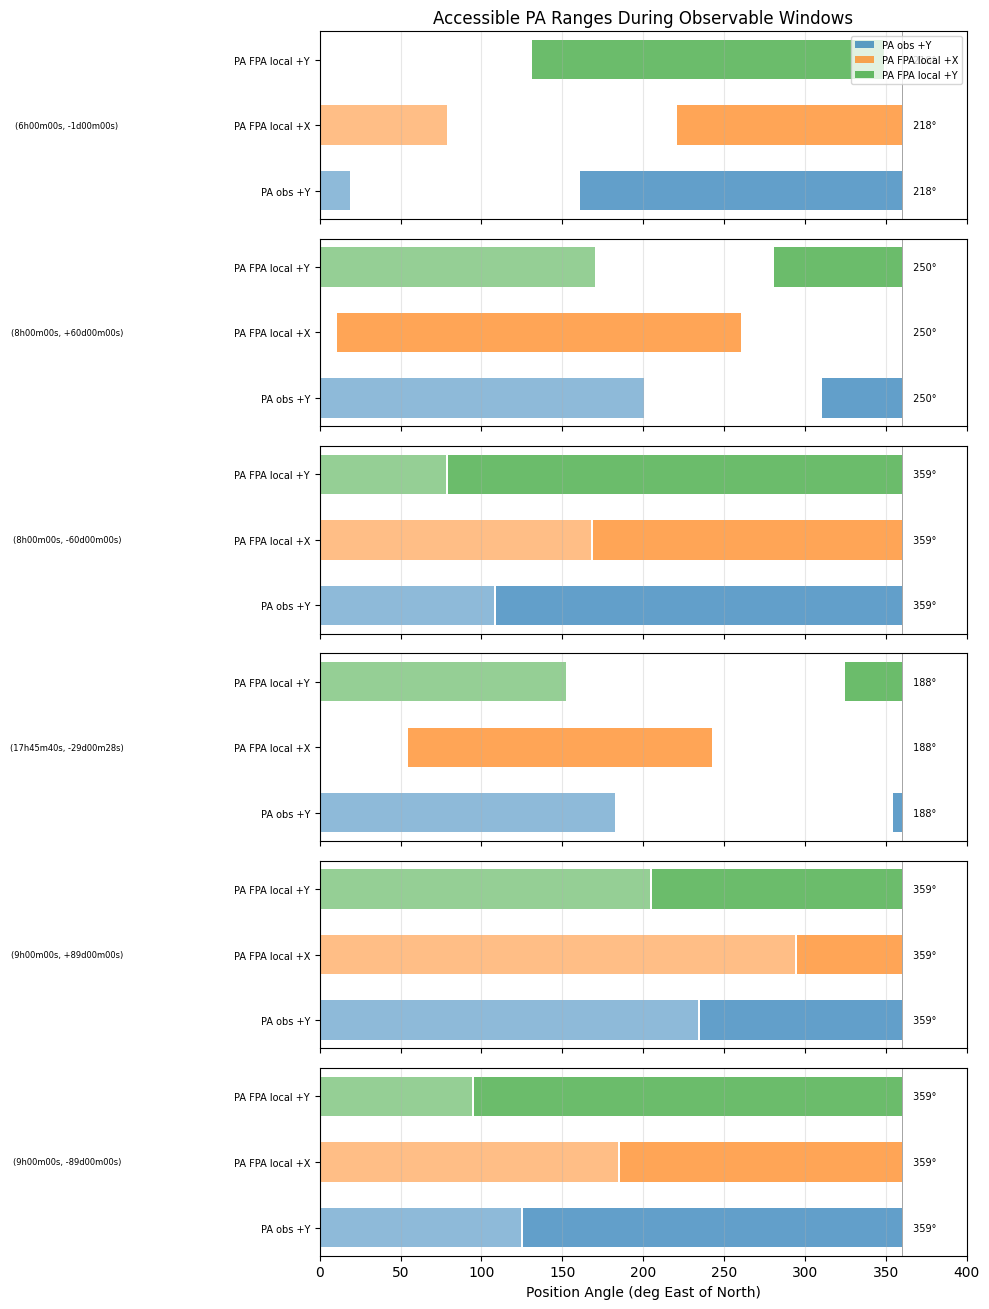

In [8]:
pa_columns = ["pa_obs_y", "pa_fpa_local_x", "pa_fpa_local_y"]
pa_display = ["PA obs +Y", "PA FPA local +X", "PA FPA local +Y"]
target_labels = list(c.df_results.index.levels[0])

fig, axes = plt.subplots(len(target_labels), 1, figsize=(10, 2.2 * len(target_labels)),
                         sharex=True)
if len(target_labels) == 1:
    axes = [axes]

bar_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, label in enumerate(target_labels):
    ax = axes[i]
    df_t = c.df_results.xs(label, level=0)
    good = df_t["good_angles"].astype(bool).values

    if not np.any(good):
        ax.text(0.5, 0.5, "No observable days", transform=ax.transAxes,
                ha="center", va="center")
        ax.set_ylabel(label, fontsize=7, rotation=0, labelpad=80, va="center")
        continue

    y_positions = np.arange(len(pa_columns))
    for j, col in enumerate(pa_columns):
        vals = to_deg(df_t[col])[good]
        start, width = circular_range(vals)
        # Draw the bar; if it wraps, draw two segments
        if start + width <= 360:
            ax.barh(y_positions[j], width, left=start, height=0.6,
                    color=bar_colors[j], alpha=0.7, label=pa_display[j] if i == 0 else "")
        else:
            # wraps: draw [start, 360] and [0, start+width-360]
            ax.barh(y_positions[j], 360 - start, left=start, height=0.6,
                    color=bar_colors[j], alpha=0.7, label=pa_display[j] if i == 0 else "")
            ax.barh(y_positions[j], start + width - 360, left=0, height=0.6,
                    color=bar_colors[j], alpha=0.5)
        ax.text(365, y_positions[j], f" {width:.0f}\u00b0", va="center", fontsize=7)

    ax.set_xlim(0, 400)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(pa_display, fontsize=7)
    ax.set_ylabel(label, fontsize=6, rotation=0, labelpad=120, va="center")
    ax.axvline(0, color="gray", lw=0.5)
    ax.axvline(360, color="gray", lw=0.5)
    ax.grid(axis="x", alpha=0.3)

axes[-1].set_xlabel("Position Angle (deg East of North)")
axes[0].set_title("Accessible PA Ranges During Observable Windows")
if len(target_labels) > 1:
    axes[0].legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

## 4. Multi-target Visibility Gantt Chart
Gantt-style comparison showing when each of the 6 targets is observable. Useful for scheduling multiple fields.

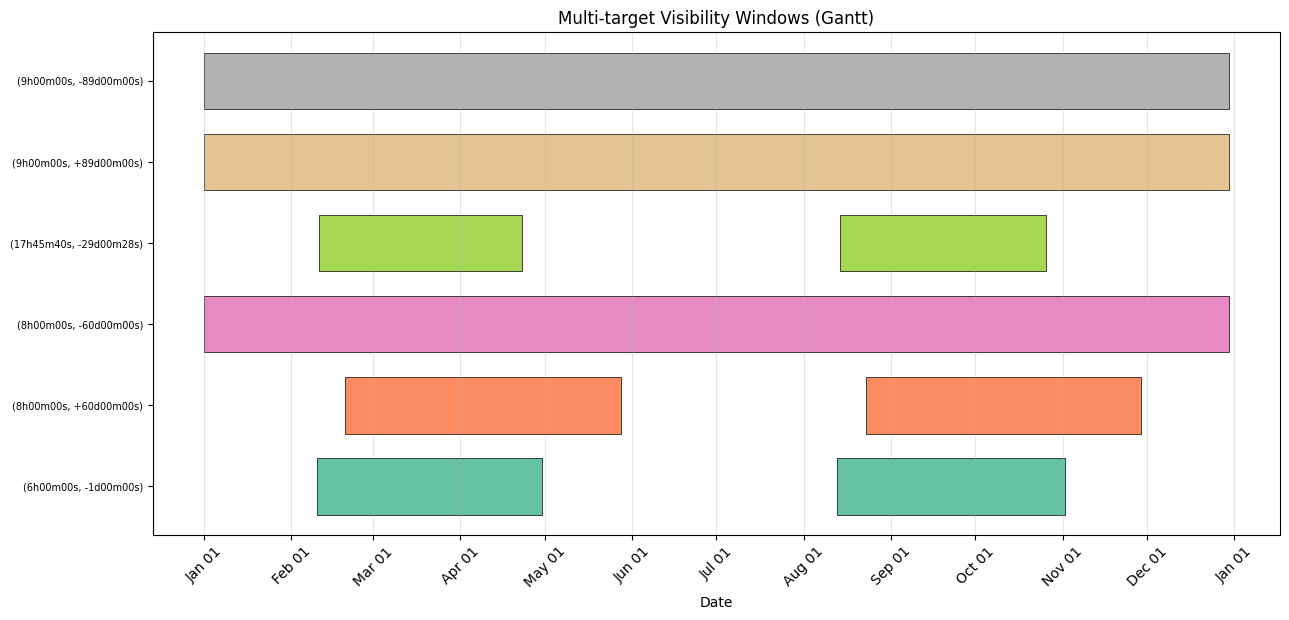

In [9]:
fig, ax = plt.subplots(figsize=(13, 0.8 * len(target_labels) + 1.5))
gantt_colors = plt.cm.Set2(np.linspace(0, 1, len(target_labels)))

for i, label in enumerate(target_labels):
    df_t = c.df_results.xs(label, level=0)
    good = df_t["good_angles"].astype(bool).values
    dates_t = get_dates(df_t)
    windows = get_observable_windows(good)

    bars = []
    for start_idx, length in windows:
        d_start = dates_t[start_idx]
        d_end = dates_t[min(start_idx + length - 1, len(dates_t) - 1)]
        bars.append((date2num(d_start), date2num(d_end) - date2num(d_start)))

    if bars:
        ax.broken_barh(bars, (i - 0.35, 0.7), facecolors=gantt_colors[i],
                       edgecolors="black", linewidth=0.5)

ax.set_yticks(range(len(target_labels)))
ax.set_yticklabels(target_labels, fontsize=7)
ax.set_ylim(-0.6, len(target_labels) - 0.4)
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
plt.xticks(rotation=45)
ax.set_xlabel("Date")
ax.set_title("Multi-target Visibility Windows (Gantt)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. All-Sky Visibility Fraction Map
Mollweide projection showing what fraction of the year each sky direction is observable.
CVZ zones appear at the ecliptic poles. Uses a coarse grid for speed.

Computing visibility for 684 sky positions...


/tmp/ipykernel_1470/1677956575.py:39: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(ra_plot_mesh, dec_plot_mesh, vis_frac_2d,


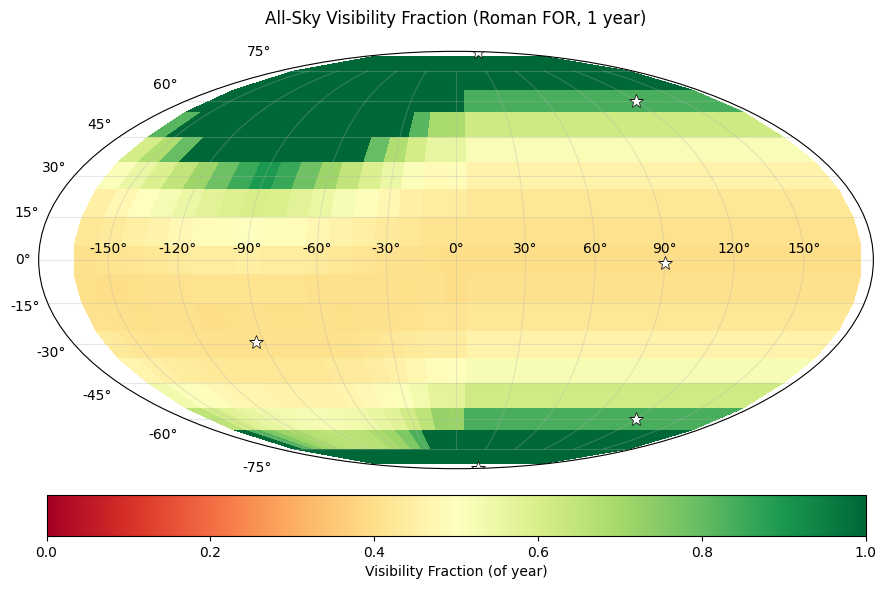

Done.


In [10]:
# NOTE: This cell takes ~1-2 minutes to run on a coarse grid.
# Reduce step to 5 for higher resolution (slower), increase to 15 for faster.

ra_grid = np.arange(0, 360, 10)   # 36 points
dec_grid = np.arange(-90, 91, 10) # 19 points
ra_mesh, dec_mesh = np.meshgrid(ra_grid, dec_grid)
ra_flat = ra_mesh.ravel()
dec_flat = dec_mesh.ravel()

# Build SkyCoord list for all grid points
sky_points = [SkyCoord(ra=r * u.deg, dec=d * u.deg, frame="icrs")
              for r, d in zip(ra_flat, dec_flat)]

print(f"Computing visibility for {len(sky_points)} sky positions...")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", AstropyWarning)
    vis_sky = compute_visibility(sky_points, report=False, fileout=None,
                                 interval_sampling_days=1,
                                 interval_start_time=None,
                                 interval_duration_days=365)
    vis_sky.get_good_angles()  # only compute good_angles, skip roll/PA for speed

# Compute visibility fraction per grid point
vis_frac = np.zeros(len(sky_points))
for i, label in enumerate(vis_sky.df_results.index.levels[0]):
    df_pt = vis_sky.df_results.xs(label, level=0)
    vis_frac[i] = df_pt["good_angles"].astype(bool).mean()

vis_frac_2d = vis_frac.reshape(ra_mesh.shape)

# Mollweide projection requires longitude in [-pi, pi] and latitude in [-pi/2, pi/2]
ra_plot = np.deg2rad(np.where(ra_grid > 180, ra_grid - 360, ra_grid))
dec_plot = np.deg2rad(dec_grid)
ra_plot_mesh, dec_plot_mesh = np.meshgrid(ra_plot, dec_plot)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="mollweide")
pcm = ax.pcolormesh(ra_plot_mesh, dec_plot_mesh, vis_frac_2d,
                     cmap="RdYlGn", shading="auto", vmin=0, vmax=1)
cbar = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, shrink=0.7)
cbar.set_label("Visibility Fraction (of year)")

# Mark the 6 test targets
for tgt in tgts:
    tgt_ra = tgt.ra.deg
    tgt_dec = tgt.dec.deg
    tgt_ra_plot = np.deg2rad(tgt_ra - 360 if tgt_ra > 180 else tgt_ra)
    tgt_dec_plot = np.deg2rad(tgt_dec)
    ax.plot(tgt_ra_plot, tgt_dec_plot, "w*", markersize=10, markeredgecolor="black", markeredgewidth=0.5)

ax.set_title("All-Sky Visibility Fraction (Roman FOR, 1 year)", fontsize=12, pad=20)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Done.")

## 7. PA Coverage Over Time (Heatmap)
Shows which position angles are accessible on each date, accounting for the roll freedom
allowed by the solar array constraint (sunang_z < 36 deg). Wider bands mean more roll freedom.

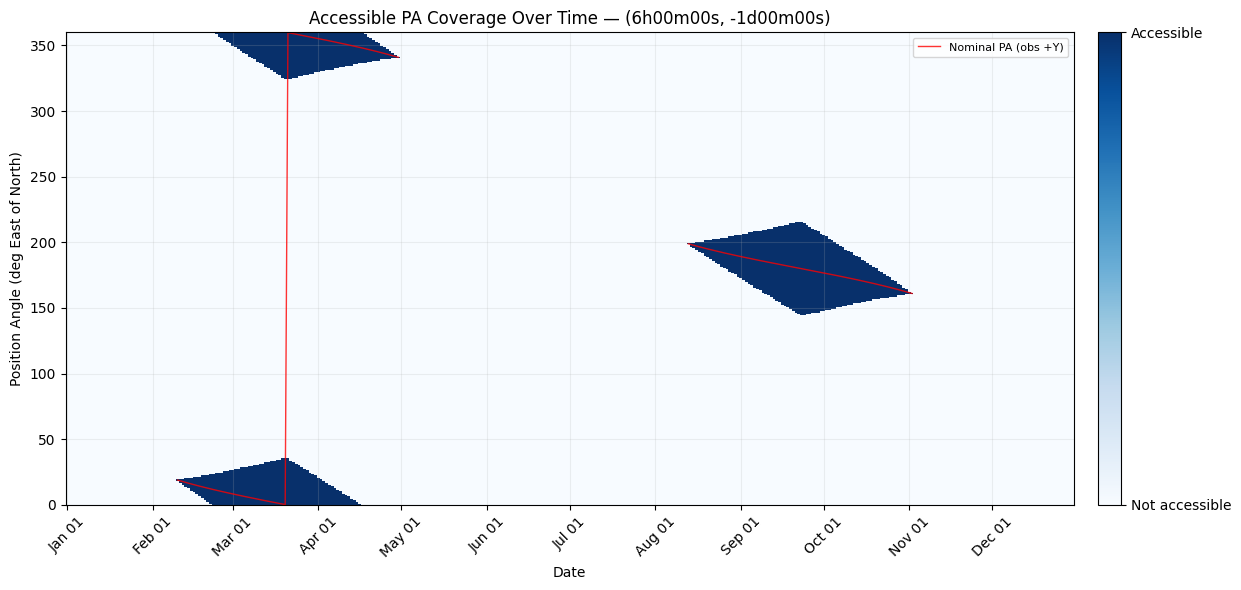

In [11]:
# Use the first target
df_pa = c.df_results.xs(target_labels[0], level=0)
dates_pa = get_dates(df_pa)
good_pa = df_pa["good_angles"].astype(bool).values
roll_nom = to_deg(df_pa["nominal_roll"])
sunz = to_deg(df_pa["sunang_z"])
pa_y_nom = to_deg(df_pa["pa_obs_y"])

# Max allowed roll offset: sunang_z increases roughly 1:1 with roll offset.
# Constraint is sunang_z < 36 deg. Margin = 36 - sunang_z_nominal.
max_offset = np.clip(36.0 - sunz, 0, 36.0)

# Build 2D accessibility map: (n_dates, 360)
pa_grid = np.arange(0, 360, 1.0)
n_dates = len(dates_pa)
accessible = np.zeros((n_dates, len(pa_grid)), dtype=float)

for t in range(n_dates):
    if not good_pa[t]:
        continue
    # PA range centered on nominal PA_obs_y, width = 2 * max_offset
    pa_center = pa_y_nom[t]
    half_w = max_offset[t]
    # Angular distance from center (circular)
    dist = np.abs(pa_grid - pa_center)
    dist = np.minimum(dist, 360 - dist)
    accessible[t, dist <= half_w] = 1.0

fig, ax = plt.subplots(figsize=(13, 6))
pcm = ax.pcolormesh(date2num(dates_pa), pa_grid, accessible.T,
                     cmap="Blues", shading="auto", vmin=0, vmax=1)

# Overlay the nominal PA line (only during observable windows)
pa_y_plot = np.where(good_pa, pa_y_nom, np.nan)
ax.plot(date2num(dates_pa), pa_y_plot, color="red", lw=1.0, alpha=0.8,
        label="Nominal PA (obs +Y)")

ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
plt.xticks(rotation=45)
ax.set_xlabel("Date")
ax.set_ylabel("Position Angle (deg East of North)")
ax.set_ylim(0, 360)
ax.set_title(f"Accessible PA Coverage Over Time \u2014 {target_labels[0]}")
ax.legend(fontsize=8, loc="upper right")

cbar = plt.colorbar(pcm, ax=ax, pad=0.02, ticks=[0, 1])
cbar.set_ticklabels(["Not accessible", "Accessible"])
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Interactive All-Sky Visibility Map (Mollweide)
Click anywhere on the Mollweide sky map below to select a target. A red **X** marker
will appear, and the visibility window + sun-target separation plots will auto-update
below.

**Requires:** `ipympl` (`pip install ipympl`) and the pre-computed `vis_frac_2d`,
`ra_grid`, `dec_grid` from the All-Sky cell above.

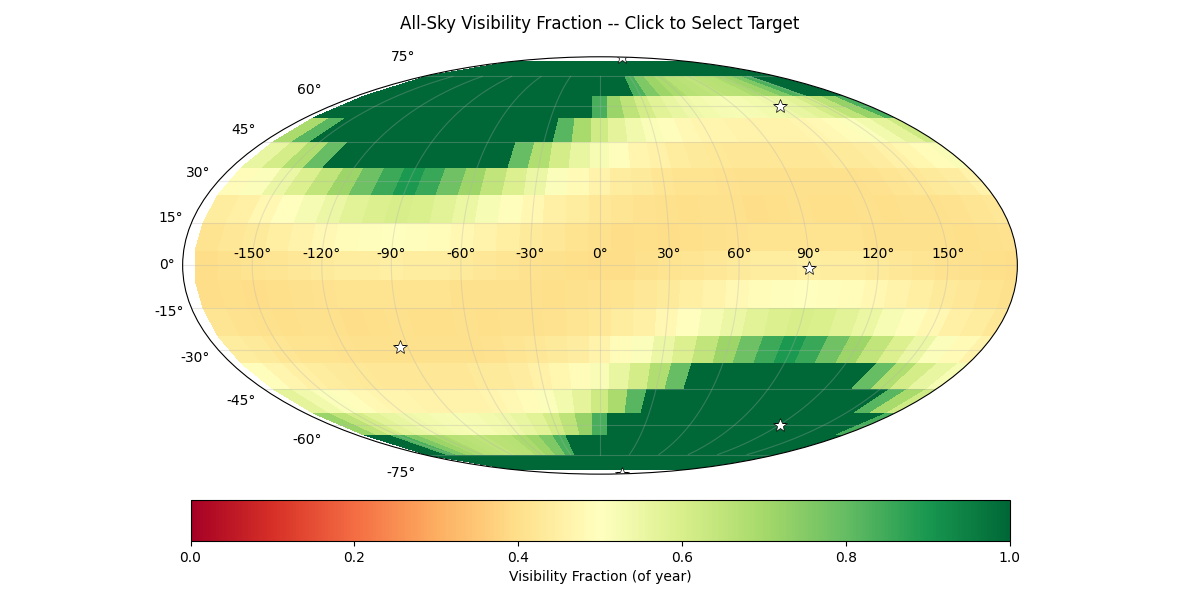

Label(value='Click on the sky map to select a target.')

Output()

In [12]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# --- Sort RA for monotonic pcolormesh (avoid warning) ---
ra_shifted = np.where(ra_grid > 180, ra_grid - 360, ra_grid)  # shift to [-180, 180)
sort_idx = np.argsort(ra_shifted)
ra_sorted_deg = ra_shifted[sort_idx]
vis_frac_sorted = vis_frac_2d[:, sort_idx]  # reorder columns to match sorted RA

ra_plot = np.deg2rad(ra_sorted_deg)
dec_plot = np.deg2rad(dec_grid)
ra_plot_mesh, dec_plot_mesh = np.meshgrid(ra_plot, dec_plot)

# --- Create the interactive Mollweide figure ---
fig_sky, ax_sky = plt.subplots(figsize=(12, 6), subplot_kw=dict(projection="mollweide"))

pcm = ax_sky.pcolormesh(ra_plot_mesh, dec_plot_mesh, vis_frac_sorted,
                         cmap="RdYlGn", shading="auto", vmin=0, vmax=1)
cbar = fig_sky.colorbar(pcm, ax=ax_sky, orientation="horizontal", pad=0.05, shrink=0.7)
cbar.set_label("Visibility Fraction (of year)")

# Mark the 6 test targets
for tgt in tgts:
    tgt_ra = tgt.ra.deg
    tgt_dec = tgt.dec.deg
    tgt_ra_plot = np.deg2rad(tgt_ra - 360 if tgt_ra > 180 else tgt_ra)
    tgt_dec_plot = np.deg2rad(tgt_dec)
    ax_sky.plot(tgt_ra_plot, tgt_dec_plot, "w*", markersize=10,
                markeredgecolor="black", markeredgewidth=0.5)

ax_sky.set_title("All-Sky Visibility Fraction -- Click to Select Target", fontsize=12, pad=20)
ax_sky.grid(True, alpha=0.3)

# Selected target marker (initially off-screen / invisible)
selected_marker, = ax_sky.plot([], [], "rx", markersize=15, markeredgewidth=3, zorder=10)

fig_sky.tight_layout()

# --- Output widgets for status + visibility plots ---
status_label = widgets.Label(value="Click on the sky map to select a target.")
vis_output = widgets.Output()

# --- Click callback ---
def on_sky_click(event):
    # Only respond to clicks inside the Mollweide axes
    if event.inaxes is not ax_sky or event.xdata is None:
        return

    lon_rad = event.xdata   # longitude in radians [-pi, pi]
    lat_rad = event.ydata   # latitude in radians [-pi/2, pi/2]

    # Convert back to RA [0, 360) and Dec [-90, 90]
    ra_deg = np.degrees(lon_rad)
    if ra_deg < 0:
        ra_deg += 360.0
    dec_deg = np.degrees(lat_rad)

    # Clamp to valid range
    ra_deg = np.clip(ra_deg, 0, 360)
    dec_deg = np.clip(dec_deg, -90, 90)

    # Update marker on the Mollweide map
    selected_marker.set_data([lon_rad], [lat_rad])
    fig_sky.canvas.draw_idle()

    status_label.value = f"Computing visibility for RA={ra_deg:.1f}, Dec={dec_deg:.1f}..."

    # Compute visibility
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", AstropyWarning)
        tgt_click = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
        vis = compute_visibility(
            tgt_click, report=False, fileout=None,
            interval_sampling_days=1,
            interval_start_time=None,
            interval_duration_days=365,
        )
        vis.compute_and_display()

    radec_label = vis.df_results.index.levels[0][0]
    df_one = vis.df_results.xs(radec_label, level=0)

    good = df_one["good_angles"].astype(bool).values
    dates_vis = get_dates(df_one)
    separation = to_deg(df_one["separation"])
    vis_fraction = good.mean()

    # Render visibility plots as a static PNG into the Output widget
    # (avoids conflicts with the widget backend used by the sky map)
    fig_v, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    # Plot 1: Visibility window
    ax1.step(dates_vis, good.astype(int), where="mid", lw=1.5, color="#1f77b4")
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(["Not in FOR", "In FOR"])
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_ylabel("Visibility")
    ax1.set_title(f"Visibility Window -- {radec_label}  (vis frac = {vis_fraction*100:.1f}%)")
    ax1.grid(alpha=0.3)

    # Plot 2: Sun-target separation
    ax2.plot(dates_vis, separation, lw=1.5, color="#1f77b4")
    ax2.axhline(54, ls="--", color="green", lw=1, label="Min (54 deg)")
    ax2.axhline(126, ls="--", color="orange", lw=1, label="Max (126 deg)")
    ax2.fill_between(dates_vis, 54, 126, alpha=0.12, color="blue", label="Observable range")
    ax2.set_ylabel("Separation (deg)")
    ax2.set_xlabel("Date")
    ax2.set_title(f"Sun-Target Separation -- {radec_label}")
    ax2.legend(fontsize=8, loc="upper right")
    ax2.grid(alpha=0.3)

    ax2.xaxis.set_major_locator(MonthLocator())
    ax2.xaxis.set_major_formatter(DateFormatter("%b %d"))
    for tick in ax2.get_xticklabels():
        tick.set_rotation(45)
    fig_v.tight_layout()

    # Save to PNG buffer and display as static image
    buf = io.BytesIO()
    fig_v.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig_v)
    buf.seek(0)

    with vis_output:
        clear_output(wait=True)
        from IPython.display import Image as IPyImage
        display(IPyImage(data=buf.read()))

    status_label.value = (
        f"Selected: RA={ra_deg:.1f}, Dec={dec_deg:.1f} -- "
        f"{radec_label} -- Vis: {vis_fraction*100:.1f}%"
    )

# Register the click handler
fig_sky.canvas.mpl_connect("button_press_event", on_sky_click)

plt.show()
display(status_label)
display(vis_output)

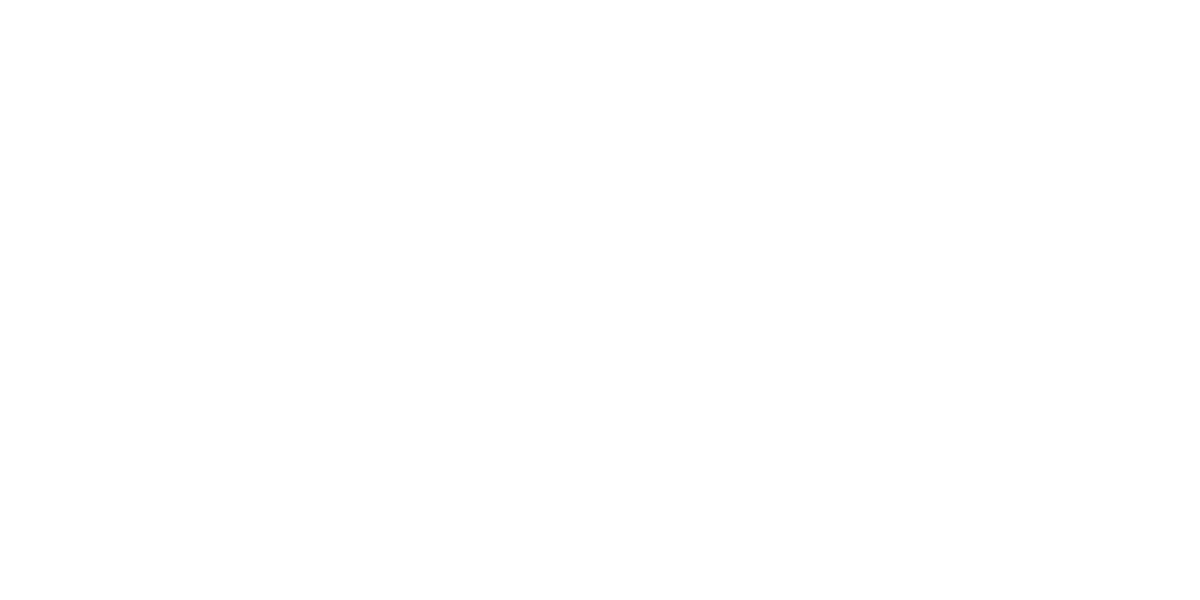

Label(value='Click on the sky map to select targets.')

Output()

Output()

In [13]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# --- Sort RA for monotonic pcolormesh (avoid warning) ---
ra_shifted = np.where(ra_grid > 180, ra_grid - 360, ra_grid)  # shift to [-180, 180)
sort_idx = np.argsort(ra_shifted)
ra_sorted_deg = ra_shifted[sort_idx]
vis_frac_sorted = vis_frac_2d[:, sort_idx]  # reorder columns to match sorted RA

ra_plot = np.deg2rad(ra_sorted_deg)
dec_plot = np.deg2rad(dec_grid)
ra_plot_mesh, dec_plot_mesh = np.meshgrid(ra_plot, dec_plot)

# --- Create the interactive Mollweide figure ---
fig_sky, ax_sky = plt.subplots(figsize=(12, 6), subplot_kw=dict(projection="mollweide"))

pcm = ax_sky.pcolormesh(ra_plot_mesh, dec_plot_mesh, vis_frac_sorted,
                         cmap="RdYlGn", shading="auto", vmin=0, vmax=1)
cbar = fig_sky.colorbar(pcm, ax=ax_sky, orientation="horizontal", pad=0.05, shrink=0.7)
cbar.set_label("Visibility Fraction (of year)")

# Mark the 6 test targets
for tgt in tgts:
    tgt_ra = tgt.ra.deg
    tgt_dec = tgt.dec.deg
    tgt_ra_plot = np.deg2rad(tgt_ra - 360 if tgt_ra > 180 else tgt_ra)
    tgt_dec_plot = np.deg2rad(tgt_dec)
    ax_sky.plot(tgt_ra_plot, tgt_dec_plot, "w*", markersize=10,
                markeredgecolor="black", markeredgewidth=0.5)

ax_sky.set_title("All-Sky Visibility Fraction -- Click to Select Targets", fontsize=12, pad=20)
ax_sky.grid(True, alpha=0.3)
fig_sky.tight_layout()

# --- Output widgets for status + visibility/Gantt plots ---
status_label = widgets.Label(value="Click on the sky map to select targets.")
vis_output = widgets.Output()
gantt_output = widgets.Output()

selected_targets = []
selected_markers = []


def _render_latest_visibility(radec_label, dates_vis, good, separation, vis_fraction, is_cvz):
    """Render the latest clicked target's visibility diagnostics."""
    fig_v, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    title_suffix = " [CVZ]" if is_cvz else ""

    ax1.step(dates_vis, good.astype(int), where="mid", lw=1.5, color="#1f77b4")
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(["Not in FOR", "In FOR"])
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_ylabel("Visibility")
    ax1.set_title(f"Visibility Window -- {radec_label}{title_suffix}  (vis frac = {vis_fraction*100:.1f}%)")
    ax1.grid(alpha=0.3)

    ax2.plot(dates_vis, separation, lw=1.5, color="#1f77b4")
    ax2.axhline(54, ls="--", color="green", lw=1, label="Min (54 deg)")
    ax2.axhline(126, ls="--", color="orange", lw=1, label="Max (126 deg)")
    ax2.fill_between(dates_vis, 54, 126, alpha=0.12, color="blue", label="Observable range")
    ax2.set_ylabel("Separation (deg)")
    ax2.set_xlabel("Date")
    ax2.set_title(f"Sun-Target Separation -- {radec_label}")
    ax2.legend(fontsize=8, loc="upper right")
    ax2.grid(alpha=0.3)

    ax2.xaxis.set_major_locator(MonthLocator())
    ax2.xaxis.set_major_formatter(DateFormatter("%b %d"))
    for tick in ax2.get_xticklabels():
        tick.set_rotation(45)
    fig_v.tight_layout()

    buf = io.BytesIO()
    fig_v.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig_v)
    buf.seek(0)

    with vis_output:
        clear_output(wait=True)
        from IPython.display import Image as IPyImage
        display(IPyImage(data=buf.read()))


def _render_selected_gantt():
    """Render a cumulative Gantt chart for every clicked target."""
    if not selected_targets:
        with gantt_output:
            clear_output(wait=True)
        return

    fig_g, ax = plt.subplots(figsize=(13, 0.7 * len(selected_targets) + 1.8))
    colors = plt.cm.Set2(np.linspace(0, 1, max(len(selected_targets), 1)))

    for i, item in enumerate(selected_targets):
        windows = get_observable_windows(item["good"])
        bars = []
        for start_idx, length in windows:
            d_start = item["dates"][start_idx]
            d_end = item["dates"][min(start_idx + length - 1, len(item["dates"]) - 1)]
            width = max(date2num(d_end) - date2num(d_start), 0.5)
            bars.append((date2num(d_start), width))

        facecolor = "#2ca02c" if item["is_cvz"] else colors[i]
        if bars:
            ax.broken_barh(bars, (i - 0.35, 0.7), facecolors=facecolor,
                           edgecolors="black", linewidth=0.5)
        else:
            ax.text(0.5, i, "No observable days", transform=ax.get_yaxis_transform(),
                    ha="center", va="center", fontsize=8, color="crimson")

    labels = [
        f"{i+1}: RA={item['ra_deg']:.1f}, Dec={item['dec_deg']:.1f}"
        f"{' [CVZ]' if item['is_cvz'] else ''}"
        for i, item in enumerate(selected_targets)
    ]
    ax.set_yticks(range(len(selected_targets)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_ylim(-0.6, len(selected_targets) - 0.4)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
    ax.set_xlabel("Date")
    ax.set_title("Selected-target Visibility Windows (Gantt)")
    ax.grid(axis="x", alpha=0.3)
    fig_g.tight_layout()

    buf = io.BytesIO()
    fig_g.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig_g)
    buf.seek(0)

    with gantt_output:
        clear_output(wait=True)
        from IPython.display import Image as IPyImage
        display(IPyImage(data=buf.read()))


# --- Click callback ---
def on_sky_click(event):
    # Only respond to clicks inside the Mollweide axes
    if event.inaxes is not ax_sky or event.xdata is None:
        return

    lon_rad = event.xdata   # longitude in radians [-pi, pi]
    lat_rad = event.ydata   # latitude in radians [-pi/2, pi/2]

    # Convert back to RA [0, 360) and Dec [-90, 90]
    ra_deg = np.degrees(lon_rad)
    if ra_deg < 0:
        ra_deg += 360.0
    dec_deg = np.degrees(lat_rad)

    # Clamp to valid range
    ra_deg = np.clip(ra_deg, 0, 360)
    dec_deg = np.clip(dec_deg, -90, 90)

    status_label.value = f"Computing visibility for RA={ra_deg:.1f}, Dec={dec_deg:.1f}..."

    # Compute visibility
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", AstropyWarning)
        tgt_click = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
        vis = compute_visibility(
            tgt_click, report=False, fileout=None,
            interval_sampling_days=1,
            interval_start_time=None,
            interval_duration_days=365,
        )
        vis.compute_and_display()

    radec_label = vis.df_results.index.levels[0][0]
    df_one = vis.df_results.xs(radec_label, level=0)

    good = df_one["good_angles"].astype(bool).values
    dates_vis = get_dates(df_one)
    separation = to_deg(df_one["separation"])
    is_cvz, vis_fraction, cvz_info = check_cvz_status(df_one)

    marker_color = "limegreen" if is_cvz else "red"
    marker, = ax_sky.plot([lon_rad], [lat_rad], marker="x", linestyle="None",
                          color=marker_color, markersize=15, markeredgewidth=3, zorder=10)
    selected_markers.append(marker)

    selected_targets.append(dict(
        label=radec_label,
        ra_deg=float(ra_deg),
        dec_deg=float(dec_deg),
        dates=dates_vis,
        good=good,
        separation=separation,
        is_cvz=bool(is_cvz),
        vis_fraction=float(vis_fraction),
    ))

    fig_sky.canvas.draw_idle()
    _render_latest_visibility(radec_label, dates_vis, good, separation, vis_fraction, is_cvz)
    _render_selected_gantt()

    status_label.value = (
        f"Selected {len(selected_targets)} target(s). Latest: RA={ra_deg:.1f}, Dec={dec_deg:.1f} -- "
        f"{radec_label} -- Vis: {vis_fraction*100:.1f}% -- "
        f"{'CVZ' if is_cvz else 'not CVZ'}"
    )

# Register the click handler
fig_sky.canvas.mpl_connect("button_press_event", on_sky_click)

plt.show()
display(status_label)
display(vis_output)
display(gantt_output)
